In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error

In [38]:
df = pd.read_csv('dataset/shipping.csv')
df.head(8)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


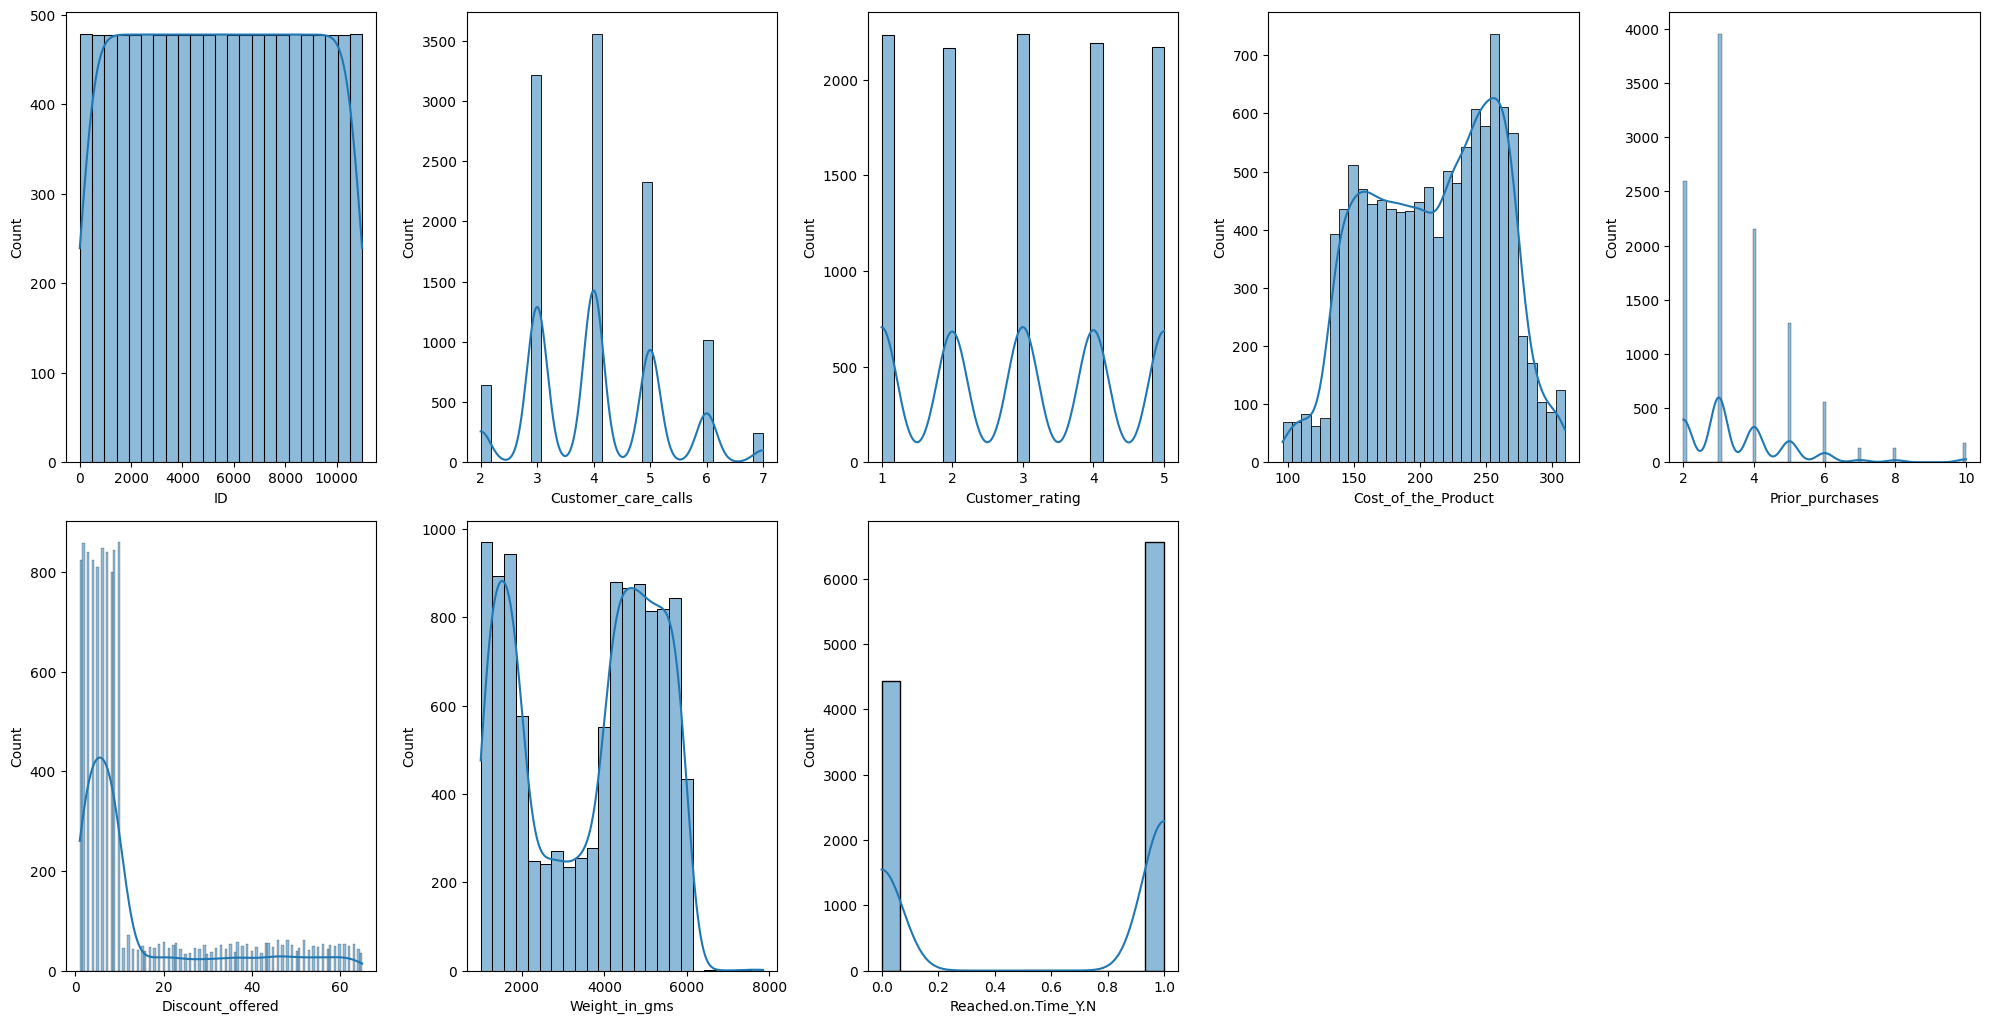

In [40]:
plt.figure(figsize = (20, 15))
plotnumber = 1
num_cols = [col for col in df.columns if df[col].dtype != 'object']

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        skewness = df[column].skew()
        sns.histplot(df[column], kde=True, label=f"Skew = {skewness:.3f}")
        plt.xlabel(column)
        
    plotnumber += 1

plt.tight_layout()
plt.show()

In [41]:
df1=df.copy()
df1=pd.get_dummies(df1,columns=['Mode_of_Shipment','Product_importance','Gender'],drop_first=True)
df1

,ID,Warehouse_block,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,1,D,4,2,177,3,44,1233,1,False,False,True,False,False
1,2,F,4,5,216,2,59,3088,1,False,False,True,False,True
2,3,A,2,2,183,4,48,3374,1,False,False,True,False,True
3,4,B,3,3,176,4,10,1177,1,False,False,False,True,True
4,5,C,2,2,184,3,46,2484,1,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,4,1,252,5,1,1538,1,False,True,False,True,False
10995,10996,B,4,1,232,5,6,1247,0,False,True,False,True,False
10996,10997,C,5,4,242,5,4,1155,0,False,True,True,False,False
10997,10998,F,5,2,223,6,2,1210,0,False,True,False,True,True


In [42]:
from sklearn.calibration import LabelEncoder


enc = LabelEncoder()
df1['Warehouse_block']=enc.fit_transform(df1['Warehouse_block'])
df1

,ID,Warehouse_block,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,1,3,4,2,177,3,44,1233,1,False,False,True,False,False
1,2,4,4,5,216,2,59,3088,1,False,False,True,False,True
2,3,0,2,2,183,4,48,3374,1,False,False,True,False,True
3,4,1,3,3,176,4,10,1177,1,False,False,False,True,True
4,5,2,2,2,184,3,46,2484,1,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,0,4,1,252,5,1,1538,1,False,True,False,True,False
10995,10996,1,4,1,232,5,6,1247,0,False,True,False,True,False
10996,10997,2,5,4,242,5,4,1155,0,False,True,True,False,False
10997,10998,4,5,2,223,6,2,1210,0,False,True,False,True,True


In [44]:
x = df1.drop(['Reached.on.Time_Y.N', 'ID'], axis=1)
x

,Warehouse_block,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,3,4,2,177,3,44,1233,False,False,True,False,False
1,4,4,5,216,2,59,3088,False,False,True,False,True
2,0,2,2,183,4,48,3374,False,False,True,False,True
3,1,3,3,176,4,10,1177,False,False,False,True,True
4,2,2,2,184,3,46,2484,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,0,4,1,252,5,1,1538,False,True,False,True,False
10995,1,4,1,232,5,6,1247,False,True,False,True,False
10996,2,5,4,242,5,4,1155,False,True,True,False,False
10997,4,5,2,223,6,2,1210,False,True,False,True,True


In [45]:
# target
y = df1['Reached.on.Time_Y.N']

In [46]:
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2,random_state=42)

In [47]:
#Regression (Linear)
reg = LinearRegression()
reg.fit(x_train, y_train)
y_reg = reg.predict(x_test)

In [48]:
mean_absolute_error(y_test, y_reg)

0.41055124263264237

In [49]:
mean_squared_error(y_test, y_reg)

0.19652638673025613

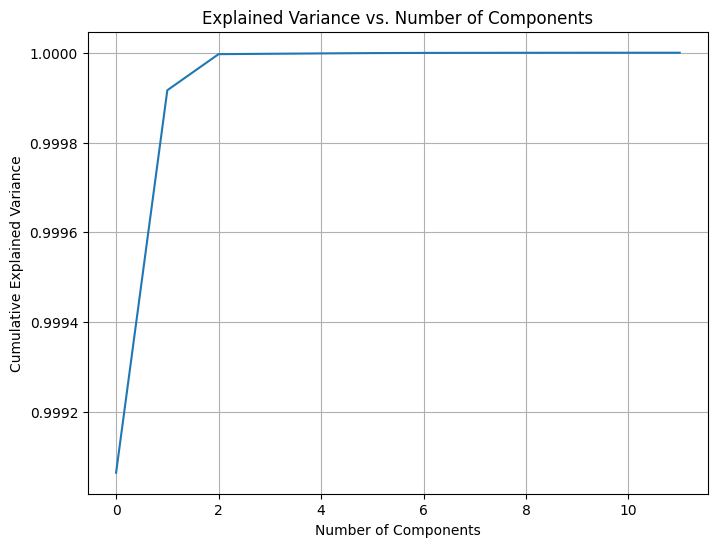

In [58]:
# PCA / LDA

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


pca = PCA().fit(x)

plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

In [66]:

# PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(x_train)
X_test_pca = pca.transform(x_test)

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)
print(f'PCA-based Linear Regression MSE: {mean_squared_error(y_test, y_pred_pca)}')
print(f'PCA-based Linear Regression MAE: {mean_absolute_error(y_test, y_pred_pca)}\n')


# LDA
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(x_train, round(y_train))
X_test_lda = lda.transform(x_test)

lr_lda = LinearRegression()
lr_lda.fit(X_train_lda, y_train)
y_pred_lda = lr_lda.predict(X_test_lda)
print(f'LDA-based Linear Regression MSE: {mean_squared_error(y_test, y_pred_lda)}')
print(f'LDA-based Linear Regression MAE: {mean_absolute_error(y_test, y_pred_lda)}')

PCA-based Linear Regression MSE: 0.21946419004100895
PCA-based Linear Regression MAE: 0.4399726452618009

LDA-based Linear Regression MSE: 0.19652638673025608
LDA-based Linear Regression MAE: 0.4105512426326416


In [67]:
#Classification(Logistic regression)
logistic_reg = LogisticRegression()

logistic_reg.fit(x_train, y_train)

y_pred = logistic_reg.predict(x_test)
y_pred

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([1, 0, 0, ..., 1, 0, 0], dtype=int64)

In [68]:
# F1 score
f1 = f1_score(y_test, y_pred)
print(f1)

0.6914440572977159


In [69]:
#accuracy

acc = accuracy_score(y_test, y_pred)
print(acc)

0.6377272727272727


In [72]:
# PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(x_train)
X_test_pca = pca.transform(x_test)

logreg_pca = LogisticRegression()
logreg_pca.fit(X_train_pca, y_train)
y_pred_pca = logreg_pca.predict(X_test_pca)
print(f'PCA-based Logistic Regression accuracy: {accuracy_score(y_test, y_pred_pca)}')
print(f'PCA-based Logistic Regression f1: {f1_score(y_test, y_pred_pca)}\n')


# LDA
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(x_train, round(y_train))
X_test_lda = lda.transform(x_test)

logreg_lda = LogisticRegression()
logreg_lda.fit(X_train_lda, y_train)
y_pred_lda = logreg_lda.predict(X_test_lda)
print(f'LDA-based Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lda)}')
print(f'LDA-based Logistic Regression f1: {f1_score(y_test, y_pred_lda)}')

PCA-based Logistic Regression accuracy: 0.6422727272727272
PCA-based Logistic Regression f1: 0.7210209145693016

LDA-based Logistic Regression accuracy: 0.6522727272727272
LDA-based Logistic Regression f1: 0.7096774193548387


In [ ]:
#После применения снижения размерности PCA/LDA резултаты ошибок улучшились